In [31]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [1]:
#pip install -e ..

In [32]:
from proj2dhullsampler import HistoryMatching

In [33]:
# Load data
obs_nc = xr.open_dataset('/glade/u/home/qingyuany/repos/spatialtuning/data/interpolated_obs.nc')
obs_tab = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/obs_tab.csv', index_col = 0).squeeze('columns')
obs_tab

para = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/para.csv', index_col=0)

ppe_nc = xr.open_dataset('/glade/u/home/qingyuany/repos/spatialtuning/data/ppe.nc')
ppe_tab = pd.read_csv('/glade/u/home/qingyuany/repos/spatialtuning/data/ppe_tab.csv', index_col = 0)


In [34]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "proj2dsampler_test"


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "tlwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [35]:
lat_bins = np.arange(-75, 76, 20) 

In [36]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})
man_sel_locations2 = pd.Series({"nm": "SWCF", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1, man_sel_locations2], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359
1,SWCF,4,7,1,359


In [37]:
test_case = HistoryMatching(working_dir, case_name)

In [38]:
test_case.create_case(para, [ppe_tab, obs_tab], ppe_nc, obs_nc, obs_dict,
                     lat_bins, manul_ppe_info, n_sample = 1000000)




Start creating new case
Check on nan variables passes: nan variables matching between obs and simulation
obs_shape: (49,), and ppe shape: (99, 49)
Manual and zonal indices match
Tabulated and processed data indices match
obs and ppe variable names match


In [39]:
test_case.prep_case.sensitivity_emulation(n_cpus=4)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [48]:
test_case.load_case()
test_case.create_mask(threshold_level=1.5)
test_case.create_mask(threshold_level=2.0)
test_case.create_mask(threshold_level=2.5)



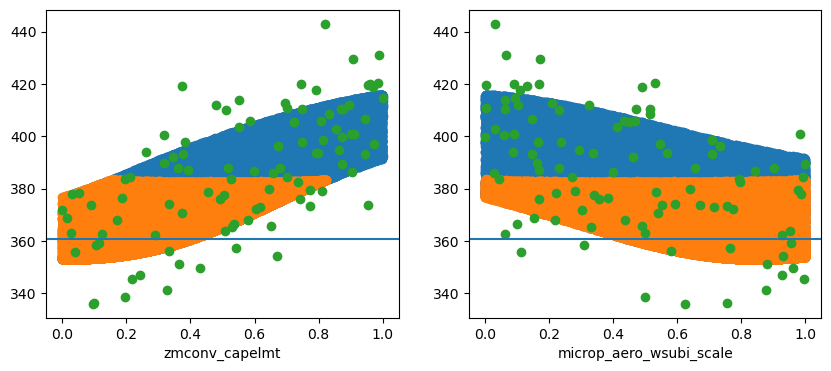

In [54]:
test_case.load_mask(threshold_level = 1.5)
test_case.visualize_check('filter_precip099')

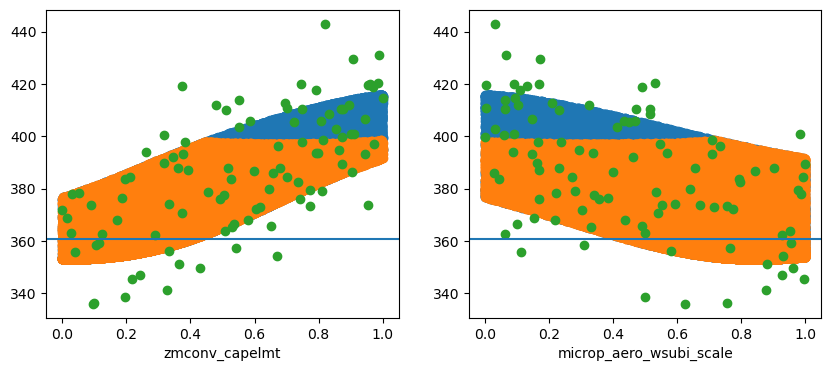

In [52]:
test_case.load_mask(threshold_level = 2.5)
test_case.visualize_check('filter_precip099')